## 1. Import Libraries

In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, recall_score

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

: 

## 2. Load Train and Test data

In [21]:
TRAIN_FILE_PATH_1 = '../data/train/mental_heath_january.csv'
TRAIN_FILE_PATH_2 = '../data/train/mental_heath_february.csv'
TRAIN_FILE_PATH_3 = '../data/train/mental_heath_march.csv'

df_train = pd.read_csv(TRAIN_FILE_PATH_1)
df_train = pd.concat([df_train, pd.read_csv(TRAIN_FILE_PATH_2)], ignore_index=True)
df_train = pd.concat([df_train, pd.read_csv(TRAIN_FILE_PATH_3)], ignore_index=True)

print("Train shape:", df_train.shape)
df_train.head()

Train shape: (49612, 3)


,Unique_ID,text,status
0,16433.0,I cannot imagine how anyone could want to be i...,Suicidal
1,15506.0,I just do not have anyone else to talk to abou...,Very Negative
2,52213.0,feeling of body falling anyone else gets this ...,Negative
3,42724.0,is cry inside please oh please let it rain so ...,Normal
4,37612.0,News Releases from the banquet = almost done! ...,Normal


## Setup MLFlow

In [22]:
import mlflow

mlflow.set_tracking_uri("http://ec2-18-136-206-38.ap-southeast-1.compute.amazonaws.com/")
mlflow.set_experiment("mental-health-sentiment-analysis")
run = mlflow.start_run(run_name="baseline-logistic-regression-tfidf")


In [23]:
TEXT_COL = "text"
LABEL_COL = "status" 

## 3. Data cleaning and Pre-processing
the dataset already do these data cleaning steps
- Removed rows with missing text or labels.
- Dropped duplicate posts based on text.
- Normalized whitespace and basic formatting via regex.
- Filtered out extremely short and extremely long texts to remove non‑informative samples.

In [24]:
import re
import string
import nltk
from nltk.tokenize import word_tokenize

# ดาวน์โหลดทรัพยากรสำหรับ Preprocessing
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sahat\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sahat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [25]:
def clean_text(text):
    # 1. Lowercasing
    text = text.lower()

    # 2. remove special characters ที่ไม่ใช่ ASCII (เช่น â, €, š)
    text = text.encode("ascii", "ignore").decode()

    # 3. remove punctuation except (! and ?)
    text = re.sub(r'[^a-z0-9\s!?]', '', text)
    
    return text

# --- ตัวอย่างการทดสอบใช้งาน ---
test_input = "I'm so happy! It's 100% amazing?? â € š"
cleaned = clean_text(test_input)
print(f"Original: {test_input}")
print(f"Cleaned:  {cleaned}")
# Output ที่ได้จะเป็น: "im happy ! 100 amazing ??"

Original: I'm so happy! It's 100% amazing?? â € š
Cleaned:  im so happy! its 100 amazing??   


In [26]:
## encode label
label2id = {
    "Normal": 0,
    "Negative": 1,
    "Very Negative": 2,
    "Suicidal": 3,
}

if df_train[LABEL_COL].dtype == object:
    df_train["label_id"] = df_train[LABEL_COL].map(label2id)
    LABEL_COL_NUM = "label_id"
else:
    LABEL_COL_NUM = LABEL_COL

df_train[[TEXT_COL, LABEL_COL, LABEL_COL_NUM]].head()

,text,status,label_id
0,I cannot imagine how anyone could want to be i...,Suicidal,3
1,I just do not have anyone else to talk to abou...,Very Negative,2
2,feeling of body falling anyone else gets this ...,Negative,1
3,is cry inside please oh please let it rain so ...,Normal,0
4,News Releases from the banquet = almost done! ...,Normal,0


## 4. Train test split

In [27]:
df_train['cleaned_text'] = df_train[TEXT_COL].apply(clean_text)
X = df_train['cleaned_text']
y = df_train['label_id']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.1, 
    random_state=21, 
    stratify=y
)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)}")

Train size: 44650 | Val size: 4962


In [28]:
# log experiment parameters
mlflow.log_param("data_size", len(df_train))
mlflow.log_param("test_size", 0.1)
mlflow.log_param("random_state", 21)

21

## 6. Traning model

In [29]:
# define model
# 3. สร้าง ML Pipeline
# เราจะรวม Tfidf และ LogisticRegression ไว้ด้วยกันเพื่อให้จัดการข้อมูลได้ง่ายในขั้นตอน Deployment
baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=5000)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

baseline_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [30]:
# 5. Evaluation (ตามคำแนะนำของอาจารย์)
y_pred = baseline_pipeline.predict(X_val)

macro_f1 = f1_score(y_val, y_pred, average='macro')
accuracy = accuracy_score(y_val, y_pred)
macro_recall = recall_score(y_val, y_pred, average='macro')

print("--- Validation Set Evaluation ---")
print(f"Macro F1 Score: {macro_f1:.4f}")
print(f"Accuracy Score: {accuracy:.4f}")
print(f"Macro Recall Score: {macro_recall:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

--- Validation Set Evaluation ---
Macro F1 Score: 0.7653
Accuracy Score: 0.7797
Macro Recall Score: 0.7844

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90      1840
           1       0.70      0.89      0.79       550
           2       0.77      0.62      0.69      1451
           3       0.67      0.71      0.69      1121

    accuracy                           0.78      4962
   macro avg       0.76      0.78      0.77      4962
weighted avg       0.78      0.78      0.78      4962



## 6.1 ROC-AUC Curve (Validation Set)
Plot one-vs-rest ROC curves for all classes and report macro/micro AUC.

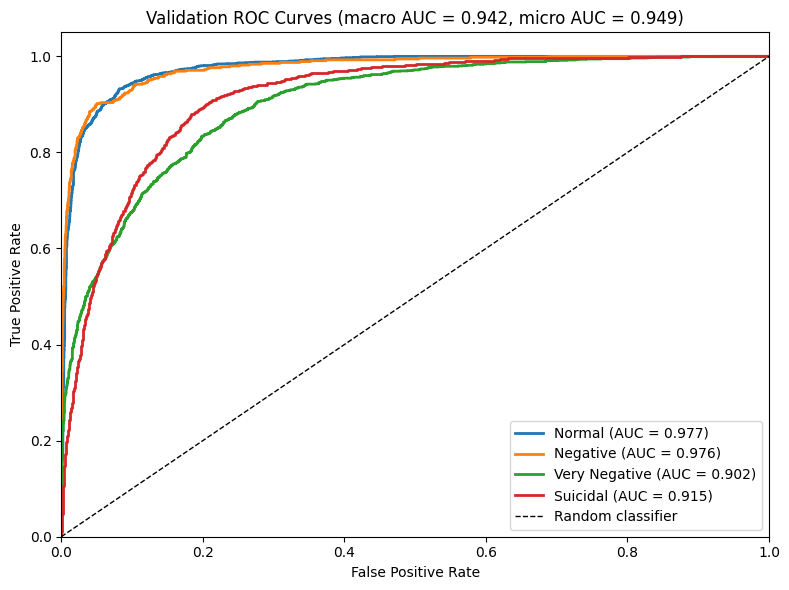

Validation Macro AUC (OvR): 0.9424
Validation Micro AUC (OvR): 0.9487


In [31]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get class probabilities from the trained pipeline
y_score = baseline_pipeline.predict_proba(X_val)

# Binarize true labels for multiclass ROC (one-vs-rest)
classes = sorted(df_train['label_id'].unique())
y_val_bin = label_binarize(y_val, classes=classes)

# Create class names mapping
id2label = {v: k for k, v in label2id.items()}
class_names = [id2label.get(c, str(c)) for c in classes]

# Per-class ROC curves
fpr = {}
tpr = {}
roc_auc = {}
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro/micro AUC scores
macro_auc = roc_auc_score(y_val_bin, y_score, average='macro', multi_class='ovr')
micro_auc = roc_auc_score(y_val_bin, y_score, average='micro', multi_class='ovr')

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], lw=2, label=f"{class_name} (AUC = {roc_auc[i]:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Validation ROC Curves (macro AUC = {macro_auc:.3f}, micro AUC = {micro_auc:.3f})')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Validation Macro AUC (OvR): {macro_auc:.4f}")
print(f"Validation Micro AUC (OvR): {micro_auc:.4f}")

In [32]:
print(tpr)


{0: array([0.00000000e+00, 5.43478261e-04, 1.46739130e-02, 1.68478261e-02,
       5.65217391e-02, 5.76086957e-02, 9.18478261e-02, 9.29347826e-02,
       1.12500000e-01, 1.12500000e-01, 1.23913043e-01, 1.23913043e-01,
       1.30434783e-01, 1.65217391e-01, 1.75543478e-01, 1.75543478e-01,
       2.36413043e-01, 2.36413043e-01, 2.59239130e-01, 2.59239130e-01,
       2.67391304e-01, 2.68478261e-01, 2.85869565e-01, 2.86956522e-01,
       3.11956522e-01, 3.11956522e-01, 3.19565217e-01, 3.19565217e-01,
       3.72282609e-01, 3.72282609e-01, 3.88043478e-01, 3.88043478e-01,
       3.98369565e-01, 3.98369565e-01, 4.10326087e-01, 4.10326087e-01,
       4.76630435e-01, 4.76630435e-01, 4.88586957e-01, 4.88586957e-01,
       4.94565217e-01, 4.94565217e-01, 4.98369565e-01, 4.98369565e-01,
       5.11956522e-01, 5.11956522e-01, 5.43478261e-01, 5.43478261e-01,
       5.58152174e-01, 5.58152174e-01, 5.61413043e-01, 5.61413043e-01,
       6.04347826e-01, 6.04347826e-01, 6.19021739e-01, 6.19021739e-01,
  

## 7. Evaluation on Test set

In [33]:
# Path inside the Kaggle dataset to the TEST FILE
TEST_FILE_PATH = '../data/test/mental_health_combined_test.csv'

df_test = pd.read_csv(TEST_FILE_PATH)


print("Test shape:", df_test.shape)
df_test.head()

Test shape: (992, 2)


,text,status
0,i don't understand whats wrong with me. i don'...,Negative
1,usually when i have anxiety just chatting with...,Negative
2,"well, i've had anxiety and panic syndrome for ...",Negative
3,"for the most minimal of things, like standing ...",Negative
4,i stay away from family and live with my roomm...,Negative


### Test set preprocess

In [34]:
if df_test[LABEL_COL].dtype == object:
    df_test[LABEL_COL_NUM] = df_test[LABEL_COL].map(label2id)

df_test[[TEXT_COL, LABEL_COL, LABEL_COL_NUM]].head()

df_test['cleaned_text'] = df_test[TEXT_COL].apply(clean_text)
X = df_test['cleaned_text']
y = df_test[LABEL_COL_NUM]

In [35]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
from mlflow.tracking import MlflowClient

# model inference
y_pred = baseline_pipeline.predict(X)
y_score = baseline_pipeline.predict_proba(X)

# Build class-name mapping for plots
classes = sorted(pd.unique(y))
id2label = {v: k for k, v in label2id.items()}
class_names = [id2label.get(c, str(c)) for c in classes]

test_macro_f1 = f1_score(y, y_pred, average='macro')
test_accuracy = accuracy_score(y, y_pred)
test_macro_recall = recall_score(y, y_pred, average='macro')
test_macro_auc = roc_auc_score(y, y_score, multi_class='ovr', average='macro')

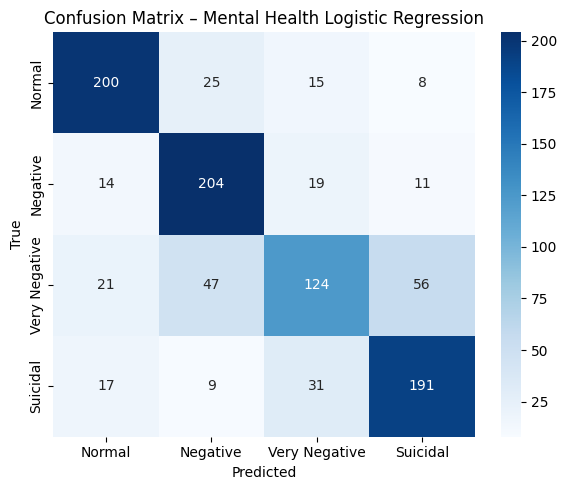

In [36]:
cm = confusion_matrix(y, y_pred)

cm_fig, cm_ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=cm_ax
)
cm_ax.set_xlabel("Predicted")
cm_ax.set_ylabel("True")
cm_ax.set_title("Confusion Matrix – Mental Health Logistic Regression")
cm_fig.tight_layout()

In [37]:
registered_model_name = "mental-health-logreg-tfidf"
registered_version = None

# Log experiment on test set

tfidf_params = baseline_pipeline.named_steps['tfidf'].get_params()
clf_params = baseline_pipeline.named_steps['clf'].get_params()

mlflow.log_params({
    "model_type": "LogisticRegression",
    "vectorizer": "TfidfVectorizer",
    "tfidf_ngram_range": str(tfidf_params.get('ngram_range')),
    "tfidf_max_features": tfidf_params.get('max_features'),
    "clf_class_weight": str(clf_params.get('class_weight')),
    "clf_max_iter": clf_params.get('max_iter'),
    "clf_C": clf_params.get('C'),
})

mlflow.log_metric("test_macro_f1", float(test_macro_f1))
mlflow.log_metric("test_accuracy", float(test_accuracy))
mlflow.log_metric("test_macro_recall", float(test_macro_recall))
mlflow.log_metric("test_macro_auc_ovr", float(test_macro_auc))

# Upload confusion matrix figure as an artifact
mlflow.log_figure(cm_fig, "plots/test_confusion_matrix.png")

# Save and register the trained model in MLflow Model Registry
mlflow.sklearn.log_model(
    sk_model=baseline_pipeline,
    artifact_path="model",
    registered_model_name=registered_model_name,
)

client = MlflowClient()
versions = client.search_model_versions(
    f"name='{registered_model_name}' and run_id='{run.info.run_id}'"
)
if versions:
    registered_version = versions[0].version

print("--- Test Set Evaluation ---")
print(f"Macro F1 Score: {test_macro_f1:.4f}")
print(f"Accuracy Score: {test_accuracy:.4f}")
print(f"Macro Recall Score: {test_macro_recall:.4f}")
print(f"Macro AUC (OvR): {test_macro_auc:.4f}")
print(f"Registered model: {registered_model_name}")
if registered_version is not None:
    print(f"Registered model version: {registered_version}")

print("\nClassification Report:")
print(classification_report(y, y_pred))

2026/04/16 00:08:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 00:08:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'mental-health-logreg-tfidf' already exists. Creating a new version of this model...
2026/04/16 00:08:16 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: mental-health-logreg-tfidf, version 6
Created version '6' of model 'mental-health-logreg-tfidf'.


--- Test Set Evaluation ---
Macro F1 Score: 0.7190
Accuracy Score: 0.7248
Macro Recall Score: 0.7248
Macro AUC (OvR): 0.9020
Registered model: mental-health-logreg-tfidf
Registered model version: 6

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       248
           1       0.72      0.82      0.77       248
           2       0.66      0.50      0.57       248
           3       0.72      0.77      0.74       248

    accuracy                           0.72       992
   macro avg       0.72      0.72      0.72       992
weighted avg       0.72      0.72      0.72       992



In [38]:
mlflow.end_run()

🏃 View run baseline-logistic-regression-tfidf at: http://ec2-18-136-206-38.ap-southeast-1.compute.amazonaws.com/#/experiments/2/runs/de416a7030e54a3f92b930b2d285ecfe
🧪 View experiment at: http://ec2-18-136-206-38.ap-southeast-1.compute.amazonaws.com/#/experiments/2
